In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

DATA_DIR = Path(r"C:\Users\Siddhartha\Sem8\MajorProject\Experiments\EComm")
OUT_DIR = DATA_DIR / "_cleaned"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Heuristic status filters (tweak after you see value_counts)
SUCCESS_REGEX = r"(complete|completed|delivered|shipped|paid)"
FAIL_REGEX    = r"(cancel|cancelled|refun|refunded|fraud|hold|failed|pending)"

def snake_case(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", "_", s)
    return s.lower()

def to_numeric_clean(x: pd.Series) -> pd.Series:
    # removes commas, currency, stray characters; keeps digits, dot, minus
    return pd.to_numeric(
        x.astype(str).str.replace(r"[^\d\.\-]", "", regex=True),
        errors="coerce"
    )

In [2]:
# Prefer a single big CSV/XLSX in the folder. If multiple, you’ll see a list.
candidates = []
candidates += list(DATA_DIR.glob("*.csv"))
candidates += list(DATA_DIR.glob("*.xlsx"))
candidates += list(DATA_DIR.glob("*.zip"))

print("Found files:")
for i, p in enumerate(candidates):
    print(f"[{i}] {p.name} ({p.stat().st_size/1e6:.1f} MB)")

assert len(candidates) > 0, "No .csv/.xlsx/.zip found in the folder."

# Pick the largest file by default (usually the main dataset)
data_path = max(candidates, key=lambda p: p.stat().st_size)
data_path

Found files:
[0] PakistanLargestEcommerceDataset.csv (106.5 MB)


WindowsPath('C:/Users/Siddhartha/Sem8/MajorProject/Experiments/EComm/PakistanLargestEcommerceDataset.csv')

In [3]:
def read_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        # Try utf-8, then latin-1 fallback
        try:
            return pd.read_csv(path, low_memory=False)
        except UnicodeDecodeError:
            return pd.read_csv(path, low_memory=False, encoding="latin1")
    elif suffix == ".xlsx":
        return pd.read_excel(path)
    elif suffix == ".zip":
        import zipfile
        with zipfile.ZipFile(path, "r") as z:
            inner = [n for n in z.namelist() if n.lower().endswith((".csv", ".xlsx"))]
            print("ZIP contains:", inner)
            assert len(inner) > 0, "Zip has no CSV/XLSX."
            # choose largest inner file
            inner_sorted = sorted(inner, key=lambda n: z.getinfo(n).file_size, reverse=True)
            target = inner_sorted[0]
            print("Reading:", target)
            with z.open(target) as f:
                if target.lower().endswith(".csv"):
                    try:
                        return pd.read_csv(f, low_memory=False)
                    except UnicodeDecodeError:
                        f.seek(0)
                        return pd.read_csv(f, low_memory=False, encoding="latin1")
                else:
                    return pd.read_excel(f)
    else:
        raise ValueError(f"Unsupported file type: {suffix}")

raw = read_dataset(data_path)
raw.shape, raw.head(3)

((1048575, 26),
     item_id    status created_at                                                sku   price  qty_ordered  grand_total increment_id    category_name_1  \
 0  211131.0  complete   7/1/2016                                  kreations_YI 06-L  1950.0          1.0       1950.0    100147443    Women's Fashion   
 1  211133.0  canceled   7/1/2016  kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...   240.0          1.0        240.0    100147444  Beauty & Grooming   
 2  211134.0  canceled   7/1/2016                                 Ego_UP0017-999-MR0  2450.0          1.0       2450.0    100147445    Women's Fashion   
 
   sales_commission_code  discount_amount payment_method Working Date BI Status      MV     Year  Month Customer Since     M-Y    FY  Customer ID  Unnamed: 21  \
 0                    \N              0.0            cod     7/1/2016     #REF!   1,950   2016.0    7.0         2016-7  7-2016  FY17          1.0          NaN   
 1                    \N              0.0 

In [4]:
raw = raw.copy()
raw.columns = [snake_case(c) for c in raw.columns]

print("Columns:", list(raw.columns))
print("\nNull % (top 20):")
display((raw.isna().mean().sort_values(ascending=False).head(20) * 100).round(2))

display(raw.head(5))

Columns: ['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered', 'grand_total', 'increment_id', 'category_name_1', 'sales_commission_code', 'discount_amount', 'payment_method', 'working_date', 'bi_status', 'mv', 'year', 'month', 'customer_since', 'my', 'fy', 'customer_id', 'unnamed_21', 'unnamed_22', 'unnamed_23', 'unnamed_24', 'unnamed_25']

Null % (top 20):


unnamed_23               100.00
unnamed_22               100.00
unnamed_25               100.00
unnamed_24               100.00
unnamed_21               100.00
sales_commission_code     57.34
category_name_1           44.27
sku                       44.26
status                    44.26
customer_since            44.26
customer_id               44.26
increment_id              44.26
grand_total               44.26
qty_ordered               44.26
created_at                44.26
item_id                   44.26
price                     44.26
discount_amount           44.26
month                     44.26
year                      44.26
dtype: float64

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,discount_amount,payment_method,working_date,bi_status,mv,year,month,customer_since,my,fy,customer_id,unnamed_21,unnamed_22,unnamed_23,unnamed_24,unnamed_25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,0.0,cod,7/1/2016,#REF!,"1,950",2016.0,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,0.0,cod,7/1/2016,Gross,240,2016.0,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,0.0,cod,7/1/2016,Gross,"2,450",2016.0,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,300.0,cod,7/1/2016,Net,360,2016.0,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,0.0,cod,7/1/2016,Valid,"1,110",2016.0,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [5]:
# Common variants seen in this dataset across different copies/notebooks
COL_CANDIDATES = {
    "created_at":   ["created_at", "createdat", "order_date", "date", "created_on", "created"],
    "customer_id":  ["customer_id", "customerid", "customer_id_", "customer", "cust_id", "customer_id__1", "customer_id_1", "customer_id__0", "customer_id__"],
    "increment_id": ["increment_id", "incrementid", "order_id", "orderid", "order_number", "order_no", "order_no_"],
    "grand_total":  ["grand_total", "grandtotal", "grand_total_", "total", "total_amount", "order_total", "order_value"],
    "status":       ["status", "order_status", "bi_status", "state"],
    "qty_ordered":  ["qty_ordered", "qty", "quantity", "item_quantity"],
    "item_price":   ["item_price", "price", "unit_price", "itemprice"],
}

def pick_col(existing_cols, candidates):
    for c in candidates:
        if c in existing_cols:
            return c
    return None

existing = set(raw.columns)

col_created = pick_col(existing, COL_CANDIDATES["created_at"])
col_cust    = pick_col(existing, COL_CANDIDATES["customer_id"])
col_order   = pick_col(existing, COL_CANDIDATES["increment_id"])
col_total   = pick_col(existing, COL_CANDIDATES["grand_total"])
col_status  = pick_col(existing, COL_CANDIDATES["status"])
col_qty     = pick_col(existing, COL_CANDIDATES["qty_ordered"])
col_price   = pick_col(existing, COL_CANDIDATES["item_price"])

print("Detected mapping:")
print(" created_at   ->", col_created)
print(" customer_id  ->", col_cust)
print(" increment_id ->", col_order)
print(" grand_total  ->", col_total)
print(" status       ->", col_status)
print(" qty_ordered  ->", col_qty)
print(" item_price   ->", col_price)

assert col_created is not None, "Could not find created_at column. Check your file columns."
assert col_cust    is not None, "Could not find customer_id column. Check your file columns."
assert col_order   is not None, "Could not find increment/order_id column. Check your file columns."

Detected mapping:
 created_at   -> created_at
 customer_id  -> customer_id
 increment_id -> increment_id
 grand_total  -> grand_total
 status       -> status
 qty_ordered  -> qty_ordered
 item_price   -> price


In [6]:
df = raw.copy()

# Parse timestamps
df["created_at"] = pd.to_datetime(df[col_created], errors="coerce", infer_datetime_format=True)

# IDs as strings (avoid float/NaN issues)
df["customer_id"] = df[col_cust].astype("string").str.strip()
df["order_id"]    = df[col_order].astype("string").str.strip()

# Monetary value
df["grand_total"] = to_numeric_clean(df[col_total]) if col_total is not None else np.nan

# Status
df["status"] = df[col_status].astype("string").str.strip().str.lower() if col_status is not None else pd.Series(["unknown"] * len(df), dtype="string")

# Optional item-level fields
if col_qty is not None:
    df["qty_ordered"] = to_numeric_clean(df[col_qty]).fillna(0)
else:
    df["qty_ordered"] = 0

if col_price is not None:
    df["item_price"] = to_numeric_clean(df[col_price]).fillna(np.nan)
else:
    df["item_price"] = np.nan

# Basic row validity
before = len(df)
df = df.dropna(subset=["created_at", "customer_id", "order_id"])
after = len(df)
print(f"Dropped {before-after} rows missing created_at/customer_id/order_id")

# Quick look at statuses
display(df["status"].value_counts(dropna=False).head(30))
df.shape

C:\Users\Siddhartha\AppData\Local\Temp\ipykernel_19444\1299949672.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["created_at"] = pd.to_datetime(df[col_created], errors="coerce", infer_datetime_format=True)


Dropped 464062 rows missing created_at/customer_id/order_id


status
complete          233685
canceled          201244
received           77289
order_refunded     59524
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
holded                31
<NA>                  15
fraud                 10
pending_paypal         7
exchange               4
\n                     4
Name: count, dtype: Int64

(584513, 28)

In [7]:
# Many versions of this dataset are item-line rows with repeated order_id.
# We'll build an order-level table using:
# - created_at: first
# - customer_id: first
# - status: most frequent (mode)
# - grand_total: max (protect against accidental repetition/noise)
# - computed_total: sum(item_price * qty_ordered) when available

def mode_or_first(x: pd.Series):
    x = x.dropna()
    if len(x) == 0:
        return np.nan
    vc = x.value_counts()
    return vc.index[0] if len(vc) else x.iloc[0]

df["line_total"] = df["item_price"] * df["qty_ordered"]

grp = df.groupby("order_id", dropna=False)

orders = grp.agg(
    created_at=("created_at", "min"),
    customer_id=("customer_id", "first"),
    status=("status", mode_or_first),
    grand_total=("grand_total", "max"),
    computed_total=("line_total", "sum"),
    n_lines=("order_id", "size"),
).reset_index()

# If computed_total is all 0/NaN, fallback to grand_total
orders["computed_total"] = orders["computed_total"].replace({0: np.nan})
orders["order_value"] = orders["grand_total"].where(orders["grand_total"].notna(), orders["computed_total"])
orders["order_value"] = orders["order_value"].where(orders["order_value"].notna(), orders["computed_total"])

# Remove weird totals
orders = orders.dropna(subset=["order_value"])
orders = orders[orders["order_value"] >= 0]

print("Order-level shape:", orders.shape)
display(orders.head(5))

# Diagnostic: how many orders had multiple lines?
display(orders["n_lines"].describe())

Order-level shape: (408744, 8)


,order_id,created_at,customer_id,status,grand_total,computed_total,n_lines,order_value
0,100001290,2016-11-23,19328.0,complete,332.0,332.0,1,332.0
1,100002382,2017-04-10,40590.0,canceled,1149.0,999.0,1,1149.0
2,100147443,2016-07-01,1.0,complete,1950.0,1950.0,1,1950.0
3,100147444,2016-07-01,2.0,canceled,240.0,240.0,1,240.0
4,100147445,2016-07-01,3.0,canceled,2450.0,2450.0,1,2450.0


count    408744.000000
mean          1.429836
std           1.288665
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          72.000000
Name: n_lines, dtype: float64

In [8]:
orders = orders.copy()
orders["is_success"] = orders["status"].fillna("").str.contains(SUCCESS_REGEX, regex=True)
orders["is_fail"]    = orders["status"].fillna("").str.contains(FAIL_REGEX, regex=True)

# Default policy:
# keep success, drop obvious failures; keep unknown only if not fail
filtered = orders[(orders["is_success"]) & (~orders["is_fail"])].copy()

print("Status counts (filtered):")
display(filtered["status"].value_counts().head(30))

print("Dropped orders:", len(orders) - len(filtered))
print("Kept orders:", len(filtered))

# Time range
print("Time range:", filtered["created_at"].min(), "->", filtered["created_at"].max())

C:\Users\Siddhartha\AppData\Local\Temp\ipykernel_19444\3936439940.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  orders["is_success"] = orders["status"].fillna("").str.contains(SUCCESS_REGEX, regex=True)
C:\Users\Siddhartha\AppData\Local\Temp\ipykernel_19444\3936439940.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  orders["is_fail"]    = orders["status"].fillna("").str.contains(FAIL_REGEX, regex=True)


Status counts (filtered):


status
complete    169493
paid           294
Name: count, dtype: Int64

Dropped orders: 238957
Kept orders: 169787
Time range: 2016-07-01 00:00:00 -> 2018-08-28 00:00:00


In [9]:
events = filtered.rename(columns={"created_at": "ts", "customer_id": "user_id"})[
    ["ts", "user_id", "order_id", "order_value"]
].copy()

events["event_type"] = "order"
events["value"] = events["order_value"].astype(float)

# add a date column (useful for daily releases)
events["date"] = events["ts"].dt.floor("D")

events = events[["ts", "date", "user_id", "event_type", "value", "order_id"]].sort_values("ts").reset_index(drop=True)

events.shape, events.head(5)

((169787, 6),
           ts       date user_id event_type  value   order_id
 0 2016-07-01 2016-07-01    59.0      order  360.0  100147709
 1 2016-07-01 2016-07-01    43.0      order  360.0  100147752
 2 2016-07-01 2016-07-01    43.0      order  360.0  100147751
 3 2016-07-01 2016-07-01    59.0      order  360.0  100147750
 4 2016-07-01 2016-07-01    43.0      order  360.0  100147749)

In [10]:
orders_out = OUT_DIR / "pak_orders_clean.parquet"
events_out = OUT_DIR / "pak_events_canonical.parquet"
events_csv = OUT_DIR / "pak_events_canonical.csv"

filtered.to_parquet(orders_out, index=False)
events.to_parquet(events_out, index=False)
events.to_csv(events_csv, index=False)

print("Saved:")
print(" ", orders_out)
print(" ", events_out)
print(" ", events_csv)

# Quality report for DP pipeline readiness
report = {
    "n_raw_rows": len(raw),
    "n_clean_orders": len(filtered),
    "n_events": len(events),
    "n_users": events["user_id"].nunique(),
    "n_days": events["date"].nunique(),
    "min_ts": str(events["ts"].min()),
    "max_ts": str(events["ts"].max()),
    "pct_missing_value": float(events["value"].isna().mean() * 100),
    "pct_zero_value": float((events["value"] == 0).mean() * 100),
}
report

Saved:
  C:\Users\Siddhartha\Sem8\MajorProject\Experiments\EComm\_cleaned\pak_orders_clean.parquet
  C:\Users\Siddhartha\Sem8\MajorProject\Experiments\EComm\_cleaned\pak_events_canonical.parquet
  C:\Users\Siddhartha\Sem8\MajorProject\Experiments\EComm\_cleaned\pak_events_canonical.csv


{'n_raw_rows': 1048575,
 'n_clean_orders': 169787,
 'n_events': 169787,
 'n_users': 67191,
 'n_days': 754,
 'min_ts': '2016-07-01 00:00:00',
 'max_ts': '2018-08-28 00:00:00',
 'pct_missing_value': 0.0,
 'pct_zero_value': 2.175078186198001}

Sanity Check


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

DATA_DIR = Path(r"C:\Users\Siddhartha\Sem8\MajorProject\Experiments\EComm")
CLEAN_DIR = DATA_DIR / "_cleaned"

events_path = CLEAN_DIR / "pak_events_canonical.parquet"
assert events_path.exists(), f"Missing file: {events_path}"

events = pd.read_parquet(events_path)
events.shape, events.head(3)

((169787, 6),
           ts       date user_id event_type  value   order_id
 0 2016-07-01 2016-07-01    59.0      order  360.0  100147709
 1 2016-07-01 2016-07-01    43.0      order  360.0  100147752
 2 2016-07-01 2016-07-01    43.0      order  360.0  100147751)

In [2]:
expected_cols = {"ts", "date", "user_id", "event_type", "value", "order_id"}
missing = expected_cols - set(events.columns)
extra = set(events.columns) - expected_cols

print("Missing expected cols:", missing)
print("Extra cols:", extra)

# Ensure datetime types
events["ts"] = pd.to_datetime(events["ts"], errors="coerce")
events["date"] = pd.to_datetime(events["date"], errors="coerce").dt.floor("D")

# Ensure user_id is string-ish
events["user_id"] = events["user_id"].astype("string").str.strip()

# Ensure numeric value
events["value"] = pd.to_numeric(events["value"], errors="coerce")

print("\nDtypes:")
print(events.dtypes)

Missing expected cols: set()
Extra cols: set()

Dtypes:
ts            datetime64[ns]
date          datetime64[ns]
user_id       string[python]
event_type            object
value                float64
order_id      string[python]
dtype: object


In [3]:
checks = {
    "n_rows": len(events),
    "n_null_ts": int(events["ts"].isna().sum()),
    "n_null_date": int(events["date"].isna().sum()),
    "n_null_user": int(events["user_id"].isna().sum()),
    "n_blank_user": int((events["user_id"].fillna("").str.len() == 0).sum()),
    "n_null_value": int(events["value"].isna().sum()),
    "n_negative_value": int((events["value"] < 0).sum()),
    "n_zero_value": int((events["value"] == 0).sum()),
    "n_dupe_order_rows": int(events.duplicated(subset=["order_id"]).sum()),
}

checks

{'n_rows': 169787,
 'n_null_ts': 0,
 'n_null_date': 0,
 'n_null_user': 0,
 'n_blank_user': 0,
 'n_null_value': 0,
 'n_negative_value': 0,
 'n_zero_value': 3693,
 'n_dupe_order_rows': 0}

In [4]:
v = events["value"].dropna()

desc = v.describe(percentiles=[0.5, 0.9, 0.95, 0.99])
display(desc)

# IQR outlier rule (quick flag, not gospel) :contentReference[oaicite:1]{index=1}
q1, q3 = v.quantile(0.25), v.quantile(0.75)
iqr = q3 - q1
lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = events[(events["value"] < lb) | (events["value"] > ub)].copy()
print("IQR bounds:", (lb, ub))
print("Outlier rows:", len(outliers), f"({len(outliers)/len(events)*100:.2f}%)")

# Show the biggest values (usually what you care about)
display(events.sort_values("value", ascending=False).head(20)[["ts","date","user_id","value","order_id"]])

count    1.697870e+05
mean     5.587727e+03
std      4.484618e+04
min      0.000000e+00
50%      1.200000e+03
90%      1.548500e+04
95%      2.443580e+04
99%      5.879200e+04
max      1.788800e+07
Name: value, dtype: float64

IQR bounds: (np.float64(-6430.5), np.float64(12181.5))
Outlier rows: 23301 (13.72%)


,ts,date,user_id,value,order_id
92645,2017-06-09,2017-06-09,50387.0,17888000.0,100323649
82643,2017-04-20,2017-04-20,42128.0,1039479.0,100296055
72571,2017-03-07,2017-03-07,36353.0,389459.0,100276526
164308,2018-03-25,2018-03-25,2675.0,353722.0,100488973
169213,2018-05-04,2018-05-04,76713.0,293475.0,100518716
168969,2018-05-04,2018-05-04,44619.0,215533.5,100518302
167682,2018-04-22,2018-04-22,105009.0,207878.0,100515229
168941,2018-05-04,2018-05-04,92276.0,206388.0,100519004
169220,2018-05-04,2018-05-04,76713.0,206388.0,100518734
24073,2016-10-29,2016-10-29,12707.0,205074.0,100188091


Date range: 2016-07-01 -> 2018-08-28
Missing days (no rows at all): 35
First 20 missing: [datetime.date(2017, 9, 30), datetime.date(2018, 5, 19), datetime.date(2018, 5, 22), datetime.date(2018, 5, 31), datetime.date(2018, 6, 6), datetime.date(2018, 6, 9), datetime.date(2018, 6, 15), datetime.date(2018, 6, 16), datetime.date(2018, 6, 17), datetime.date(2018, 6, 18), datetime.date(2018, 6, 21), datetime.date(2018, 6, 23), datetime.date(2018, 6, 24), datetime.date(2018, 6, 30), datetime.date(2018, 7, 1), datetime.date(2018, 7, 2), datetime.date(2018, 7, 12), datetime.date(2018, 7, 13), datetime.date(2018, 7, 15), datetime.date(2018, 7, 17)]
Zero-order days: 35
Longest consecutive zero-day streak: 4


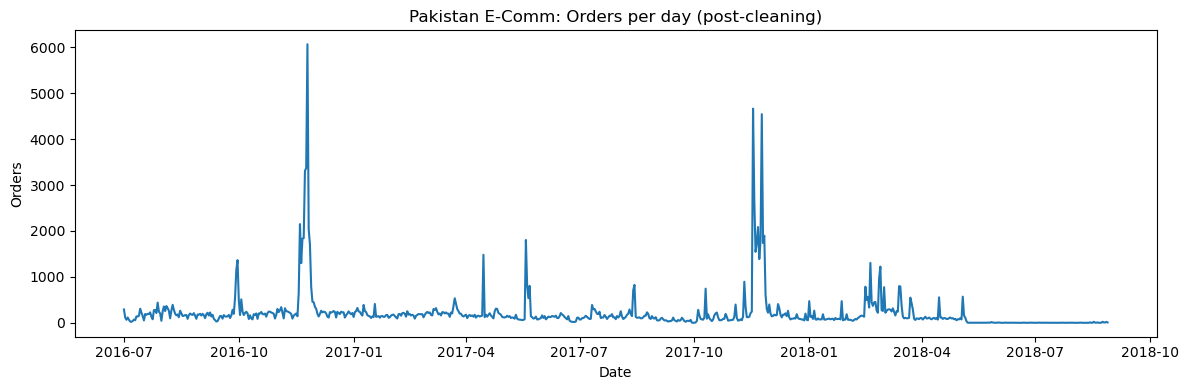

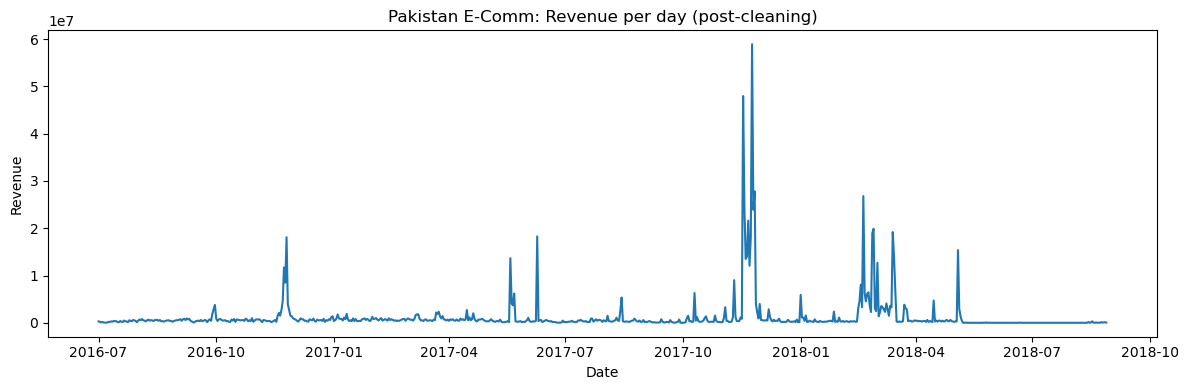

In [5]:
# Daily counts / unique users
daily = (events
         .groupby("date", dropna=False)
         .agg(
             orders=("order_id", "nunique"),
             rows=("order_id", "size"),
             dau=("user_id", "nunique"),
             revenue=("value", "sum"),
         )
         .sort_index())

# Reindex to full day range to detect gaps :contentReference[oaicite:2]{index=2}
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily_full = daily.reindex(full_idx)

missing_days = daily_full[daily_full["orders"].isna()].index
print("Date range:", full_idx.min().date(), "->", full_idx.max().date())
print("Missing days (no rows at all):", len(missing_days))
if len(missing_days) > 0:
    print("First 20 missing:", list(missing_days[:20].date))

# Zero-volume days (exists but filtered too hard)
daily_full = daily_full.fillna(0)
zero_days = daily_full[daily_full["orders"] == 0].index
print("Zero-order days:", len(zero_days))

# Find longest consecutive run of zero days
is_zero = (daily_full["orders"] == 0).astype(int).values
max_run = 0
cur = 0
for z in is_zero:
    cur = cur + 1 if z == 1 else 0
    max_run = max(max_run, cur)
print("Longest consecutive zero-day streak:", max_run)

# Plot (default matplotlib colors)
plt.figure(figsize=(12,4))
plt.plot(daily_full.index, daily_full["orders"])
plt.title("Pakistan E-Comm: Orders per day (post-cleaning)")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily_full.index, daily_full["revenue"])
plt.title("Pakistan E-Comm: Revenue per day (post-cleaning)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [6]:
problems = []

if checks["n_null_ts"] > 0:
    problems.append(f"ts has {checks['n_null_ts']} NaT values")
if checks["n_null_user"] > 0 or checks["n_blank_user"] > 0:
    problems.append(f"user_id has null/blank values: null={checks['n_null_user']}, blank={checks['n_blank_user']}")
if checks["n_null_value"] > 0:
    problems.append(f"value has {checks['n_null_value']} NaNs")
if checks["n_negative_value"] > 0:
    problems.append(f"value has {checks['n_negative_value']} negative rows")
if max_run >= 7:
    problems.append(f"Long zero-day streak detected: {max_run} days (status filter might be too strict)")

if problems:
    print("⚠️ Issues to fix before DP:")
    for p in problems:
        print(" -", p)
else:
    print("✅ Sanity checks look fine. Move to Step 2 (slice + cadence).")

✅ Sanity checks look fine. Move to Step 2 (slice + cadence).


In [7]:
# --- Fix user_id formatting (remove trailing ".0" if present) ---

# Before fix (sample)
print("Before fix (sample):")
display(events["user_id"].head(10))

# Remove trailing ".0" only if it exists at the end
events["user_id"] = (
    events["user_id"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Optional: assert no ".0" remains
assert not events["user_id"].str.endswith(".0", na=False).any(), "Some user_ids still end with .0"

print("After fix (sample):")
display(events["user_id"].head(10))

Before fix (sample):


0    59.0
1    43.0
2    43.0
3    59.0
4    43.0
5    43.0
6    43.0
7    43.0
8    43.0
9    43.0
Name: user_id, dtype: string

After fix (sample):


0    59
1    43
2    43
3    59
4    43
5    43
6    43
7    43
8    43
9    43
Name: user_id, dtype: string